In [1]:
import os
os.makedirs("outputs/figures", exist_ok=True)
os.makedirs("outputs/tables", exist_ok=True)
print("Folders ready.")

Folders ready.


In [2]:
%%writefile config.py
import numpy as np

# Domain
X_LEFT = -np.pi
X_RIGHT = np.pi
DOMAIN_LENGTH = X_RIGHT - X_LEFT

# Initial data
SIGMA = 50.0

# Resolution studies
N_DEFAULT = 101
N_CANDIDATES = [101, 151, 201, 301, 401, 601, 801]

# CFL choices
CFL_NEAR_LIMIT = 0.95
CFL_BELOW_LIMIT = 0.50

# Time windows
PLOT_INTERVAL = 0.1
T_ONE_RETURN = 2.0 * np.pi
T_TWO_RETURNS = 4.0 * np.pi

# Speed profiles
FAST_SPEED = 1.0
SLOW_SPEED_1 = 0.5
SLOW_SPEED_2 = 0.3
INTERFACE = 0.5

# Output
OUTPUT_DIR = "outputs"
FIG_DIR = "outputs/figures"
TABLE_DIR = "outputs/tables"

Writing config.py


In [3]:
%%writefile grid.py
import numpy as np

def make_periodic_grid(n, x_left=-np.pi, x_right=np.pi):
    """
    Build the periodic grid exactly as specified in the assignment.

    n: natural count including x = pi
    stored grid size is m = n - 1
    x runs from x_left to x_right - h
    """
    if n < 3:
        raise ValueError("n must be at least 3.")
    m = n - 1
    h = (x_right - x_left) / (n - 1)
    x = x_left + h * np.arange(m)
    return x, h, m

def grid_metadata(n, x_left=-np.pi, x_right=np.pi):
    x, h, m = make_periodic_grid(n, x_left, x_right)
    return {
        "n": n,
        "m": m,
        "h": h,
        "x_left": x_left,
        "x_right": x_right,
        "length": x_right - x_left,
        "x0": x[0],
        "x_last": x[-1],
    }

Writing grid.py


In [4]:
%%writefile initial_data.py
import numpy as np

def gaussian_pulse(x, sigma=50.0):
    return np.exp(-sigma * x**2)

def initial_condition(x, sigma=50.0):
    return gaussian_pulse(x, sigma=sigma)

def shifted_gaussian(x, shift=0.0, sigma=50.0):
    return np.exp(-sigma * (x - shift)**2)

Writing initial_data.py


In [5]:
%%writefile speed_profiles.py
import numpy as np

def speed_constant(x, c=1.0):
    return np.full_like(x, float(c), dtype=float)

def speed_piecewise(x, fast=1.0, slow=0.5, interface=0.5):
    c = np.full_like(x, float(slow), dtype=float)
    c[np.abs(x) < interface] = float(fast)
    return c

def speed_piecewise_half(x):
    return speed_piecewise(x, fast=1.0, slow=0.5, interface=0.5)

def speed_piecewise_point3(x):
    return speed_piecewise(x, fast=1.0, slow=0.3, interface=0.5)

Writing speed_profiles.py


In [6]:
%%writefile exact_solutions.py
import numpy as np

def gaussian(z, sigma=50.0):
    return np.exp(-sigma * z**2)

def exact_three_pulses(x, t, c=1.0, sigma=50.0):
    """
    Exact periodic-image reference used in the assignment for constant c.
    """
    return (
        gaussian(x + c * t, sigma=sigma)
        + gaussian(x + c * t - 2.0 * np.pi, sigma=sigma)
        + gaussian(x + c * t - 4.0 * np.pi, sigma=sigma)
    )

def exact_constant_periodic(x, t, c=1.0, sigma=50.0, num_images=5):
    """
    More general periodic-image reference.
    Images are centered at x + ct - 2*pi*k for k = 0,...,num_images-1.
    """
    u = np.zeros_like(x, dtype=float)
    for k in range(num_images):
        u += gaussian(x + c * t - 2.0 * np.pi * k, sigma=sigma)
    return u

Writing exact_solutions.py


In [7]:
%%writefile boundary.py
import numpy as np

def jm1(j, m):
    return (j - 1) % m

def jp1(j, m):
    return (j + 1) % m

def jm2(j, m):
    return (j - 2) % m

def jp2(j, m):
    return (j + 2) % m

def jm3(j, m):
    return (j - 3) % m

def jp3(j, m):
    return (j + 3) % m

def jm4(j, m):
    return (j - 4) % m

def jp4(j, m):
    return (j + 4) % m

def periodic_roll(u, shift):
    return np.roll(u, shift)

Writing boundary.py


In [8]:
%%writefile flux.py
import numpy as np

def compute_flux(u, c):
    return np.asarray(c, dtype=float) * np.asarray(u, dtype=float)

Writing flux.py


In [9]:
%%writefile macbf.py
import numpy as np
from flux import compute_flux

def macbf_step(u, c, dt, h):
    """
    Standard 2-2 MacCormack, backward predictor / forward corrector
    for u_t = (c u)_x.

    Predictor:
        u_tilde_j = u_j + lambda * (f_j - f_{j-1})

    Corrector:
        u^{n+1}_j = 0.5 * [u_j + u_tilde_j + lambda * (f_tilde_{j+1} - f_tilde_j)]
    """
    u = np.asarray(u, dtype=float)
    m = len(u)
    lam = dt / h

    f = compute_flux(u, c)
    u_tilde = u + lam * (f - np.roll(f, 1))

    f_tilde = compute_flux(u_tilde, c)
    u_next = 0.5 * (u + u_tilde + lam * (np.roll(f_tilde, -1) - f_tilde))
    return u_next

Writing macbf.py


In [10]:
%%writefile macfb.py
import numpy as np
from flux import compute_flux

def macfb_step(u, c, dt, h):
    """
    Standard 2-2 MacCormack, forward predictor / backward corrector
    for u_t = (c u)_x.

    Predictor:
        u_tilde_j = u_j + lambda * (f_{j+1} - f_j)

    Corrector:
        u^{n+1}_j = 0.5 * [u_j + u_tilde_j + lambda * (f_tilde_j - f_tilde_{j-1})]
    """
    u = np.asarray(u, dtype=float)
    lam = dt / h

    f = compute_flux(u, c)
    u_tilde = u + lam * (np.roll(f, -1) - f)

    f_tilde = compute_flux(u_tilde, c)
    u_next = 0.5 * (u + u_tilde + lam * (f_tilde - np.roll(f_tilde, 1)))
    return u_next

Writing macfb.py


In [11]:
%%writefile mac24bf.py
import numpy as np
from flux import compute_flux

def _backward4(f):
    """
    Fourth-order backward first derivative approximation to f_x,
    multiplied by h:
        h f_x ≈ (25 f_j - 48 f_{j-1} + 36 f_{j-2} - 16 f_{j-3} + 3 f_{j-4}) / 12
    """
    return (
        25.0 * f
        - 48.0 * np.roll(f, 1)
        + 36.0 * np.roll(f, 2)
        - 16.0 * np.roll(f, 3)
        + 3.0 * np.roll(f, 4)
    ) / 12.0

def _forward4(f):
    """
    Fourth-order forward first derivative approximation to f_x,
    multiplied by h:
        h f_x ≈ (-25 f_j + 48 f_{j+1} - 36 f_{j+2} + 16 f_{j+3} - 3 f_{j+4}) / 12
    """
    return (
        -25.0 * f
        + 48.0 * np.roll(f, -1)
        - 36.0 * np.roll(f, -2)
        + 16.0 * np.roll(f, -3)
        - 3.0 * np.roll(f, -4)
    ) / 12.0

def mac24bf_step(u, c, dt, h):
    """
    One 2-4 MacCormack step, interpreted as:
    - second-order time
    - fourth-order one-sided spatial differences
    - backward predictor / forward corrector

    This is a standard and reasonable interpretation of a 2-4 MacCormack scheme.
    """
    u = np.asarray(u, dtype=float)
    lam = dt / h

    f = compute_flux(u, c)
    u_tilde = u + lam * _backward4(f)

    f_tilde = compute_flux(u_tilde, c)
    u_next = 0.5 * (u + u_tilde + lam * _forward4(f_tilde))
    return u_next

Writing mac24bf.py


In [12]:
%%writefile mac24fb.py
import numpy as np
from flux import compute_flux

def _backward4(f):
    return (
        25.0 * f
        - 48.0 * np.roll(f, 1)
        + 36.0 * np.roll(f, 2)
        - 16.0 * np.roll(f, 3)
        + 3.0 * np.roll(f, 4)
    ) / 12.0

def _forward4(f):
    return (
        -25.0 * f
        + 48.0 * np.roll(f, -1)
        - 36.0 * np.roll(f, -2)
        + 16.0 * np.roll(f, -3)
        - 3.0 * np.roll(f, -4)
    ) / 12.0

def mac24fb_step(u, c, dt, h):
    """
    One 2-4 MacCormack step, forward predictor / backward corrector.
    """
    u = np.asarray(u, dtype=float)
    lam = dt / h

    f = compute_flux(u, c)
    u_tilde = u + lam * _forward4(f)

    f_tilde = compute_flux(u_tilde, c)
    u_next = 0.5 * (u + u_tilde + lam * _backward4(f_tilde))
    return u_next

Writing mac24fb.py


In [13]:
%%writefile rk_schemes.py
import numpy as np
from flux import compute_flux

def spatial_rhs_centered2(u, c, h):
    """
    Semi-discrete centered second-order approximation to (c u)_x.
    """
    f = compute_flux(u, c)
    return (np.roll(f, -1) - np.roll(f, 1)) / (2.0 * h)

def rk2_step(u, c, dt, h, rhs_func=spatial_rhs_centered2):
    k1 = rhs_func(u, c, h)
    k2 = rhs_func(u + 0.5 * dt * k1, c, h)
    return u + dt * k2

def rk4_step(u, c, dt, h, rhs_func=spatial_rhs_centered2):
    k1 = rhs_func(u, c, h)
    k2 = rhs_func(u + 0.5 * dt * k1, c, h)
    k3 = rhs_func(u + 0.5 * dt * k2, c, h)
    k4 = rhs_func(u + dt * k3, c, h)
    return u + (dt / 6.0) * (k1 + 2*k2 + 2*k3 + k4)

Writing rk_schemes.py


In [14]:
%%writefile time_integrators.py
import numpy as np

def compute_dt(c, h, cfl):
    cmax = float(np.max(np.abs(c)))
    if cmax <= 0.0:
        raise ValueError("cmax must be positive.")
    return cfl * h / cmax

def _save_times(t_final, save_interval):
    num = int(np.floor(t_final / save_interval + 1e-12))
    times = [k * save_interval for k in range(num + 1)]
    if abs(times[-1] - t_final) > 1e-12:
        times.append(float(t_final))
    return times

def run_solver(u0, c, h, dt, t_final, step_func=None,
               save_interval=0.1, alternate_pair=None, method_name="solver"):
    """
    Generic time driver.
    Either:
      - pass step_func
      - or pass alternate_pair=(step_a, step_b)

    Saves snapshots at t = 0, save_interval, 2*save_interval, ..., t_final.
    """
    u = np.asarray(u0, dtype=float).copy()
    t = 0.0
    step_count = 0

    targets = _save_times(t_final, save_interval)
    target_idx = 1

    times = [0.0]
    snapshots = [u.copy()]

    while t < t_final - 1e-14:
        dt_step = min(dt, t_final - t)

        if alternate_pair is not None:
            if step_count % 2 == 0:
                u = alternate_pair[0](u, c, dt_step, h)
            else:
                u = alternate_pair[1](u, c, dt_step, h)
        else:
            u = step_func(u, c, dt_step, h)

        t += dt_step
        step_count += 1

        while target_idx < len(targets) and t >= targets[target_idx] - 1e-12:
            times.append(targets[target_idx])
            snapshots.append(u.copy())
            target_idx += 1

    return {
        "times": np.array(times, dtype=float),
        "snapshots": np.array(snapshots, dtype=float),
        "dt": float(dt),
        "h": float(h),
        "num_steps": int(step_count),
        "save_interval": float(save_interval),
        "method": method_name,
    }

Writing time_integrators.py


In [15]:
%%writefile diagnostics.py
import numpy as np

def linf_error(u_num, u_exact):
    return float(np.max(np.abs(u_num - u_exact)))

def l2_error(u_num, u_exact, h):
    return float(np.sqrt(h * np.sum((u_num - u_exact)**2)))

def peak_amplitude(u):
    return float(np.max(u))

def peak_location(x, u):
    return float(x[np.argmax(u)])

def mass(u, h):
    return float(h * np.sum(u))

def pulse_width_half_max(x, u):
    """
    Rough FWHM estimate on the periodic grid.
    """
    umax = np.max(u)
    half = 0.5 * umax
    idx = np.where(u >= half)[0]
    if len(idx) < 2:
        return 0.0
    return float(x[idx[-1]] - x[idx[0]])

def return_quality(x, u_num, u_exact, h):
    return {
        "linf_error": linf_error(u_num, u_exact),
        "l2_error": l2_error(u_num, u_exact, h),
        "amplitude_num": peak_amplitude(u_num),
        "amplitude_exact": peak_amplitude(u_exact),
        "amplitude_loss": peak_amplitude(u_exact) - peak_amplitude(u_num),
        "peak_location_num": peak_location(x, u_num),
        "peak_location_exact": peak_location(x, u_exact),
        "phase_shift": peak_location(x, u_num) - peak_location(x, u_exact),
        "width_num": pulse_width_half_max(x, u_num),
        "width_exact": pulse_width_half_max(x, u_exact),
        "mass_num": mass(u_num, h),
        "mass_exact": mass(u_exact, h),
        "mass_error": mass(u_num, h) - mass(u_exact, h),
    }

def series_metric(times, snapshots, metric_func, *args):
    vals = [metric_func(s, *args) if args else metric_func(s) for s in snapshots]
    return np.asarray(times, dtype=float), np.asarray(vals, dtype=float)

Writing diagnostics.py


In [16]:
%%writefile plotting.py
import os
import numpy as np
import matplotlib.pyplot as plt

def plot_initial_condition(x, u0, savepath=None, show=True):
    plt.figure(figsize=(8, 4.5))
    plt.plot(x, u0, linewidth=2, label="initial pulse")
    plt.xlabel("x")
    plt.ylabel("u")
    plt.title("Initial Gaussian Pulse")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    if savepath:
        plt.savefig(savepath, dpi=160, bbox_inches="tight")
    if show:
        plt.show()
    else:
        plt.close()

def plot_numeric_vs_exact(x, u_num, u_exact, t, title="", savepath=None, show=True):
    plt.figure(figsize=(8, 4.8))
    plt.plot(x, u_num, linewidth=2, label="numerical")
    plt.plot(x, u_exact, linewidth=2, linestyle="--", label="exact/reference")
    plt.xlabel("x")
    plt.ylabel("u")
    plt.title(title if title else f"Numerical vs exact at t={t:.3f}")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    if savepath:
        plt.savefig(savepath, dpi=160, bbox_inches="tight")
    if show:
        plt.show()
    else:
        plt.close()

def plot_snapshots(x, snapshots, times, savepath=None, show=True):
    plt.figure(figsize=(9, 5))
    for u, t in zip(snapshots, times):
        plt.plot(x, u, label=f"t={t:.1f}")
    plt.xlabel("x")
    plt.ylabel("u")
    plt.title("Solution snapshots")
    plt.grid(True, alpha=0.3)
    plt.legend(ncol=2, fontsize=8)
    plt.tight_layout()
    if savepath:
        plt.savefig(savepath, dpi=160, bbox_inches="tight")
    if show:
        plt.show()
    else:
        plt.close()

def plot_metric_vs_time(times, values, ylabel, title, savepath=None, show=True):
    plt.figure(figsize=(8, 4.5))
    plt.plot(times, values, linewidth=2)
    plt.xlabel("t")
    plt.ylabel(ylabel)
    plt.title(title)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    if savepath:
        plt.savefig(savepath, dpi=160, bbox_inches="tight")
    if show:
        plt.show()
    else:
        plt.close()

def plot_resolution_study(n_values, errors, ylabel, title, savepath=None, show=True):
    plt.figure(figsize=(8, 4.5))
    plt.plot(n_values, errors, marker="o", linewidth=2)
    plt.xlabel("n")
    plt.ylabel(ylabel)
    plt.title(title)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    if savepath:
        plt.savefig(savepath, dpi=160, bbox_inches="tight")
    if show:
        plt.show()
    else:
        plt.close()

Writing plotting.py


In [17]:
%%writefile report_tables.py
import pandas as pd

def make_results_dataframe(records):
    return pd.DataFrame(records)

def export_csv(df, filename):
    df.to_csv(filename, index=False)
    return filename

def to_latex_table(df):
    return df.to_latex(index=False, float_format=lambda x: f"{x:.6f}")

Writing report_tables.py


In [18]:
%%writefile tests_basic.py
import numpy as np
from grid import make_periodic_grid
from speed_profiles import speed_constant
from flux import compute_flux
from macbf import macbf_step
from macfb import macfb_step
from rk_schemes import spatial_rhs_centered2

def run_basic_tests():
    x, h, m = make_periodic_grid(3)
    assert m == 2
    assert np.isclose(h, np.pi)
    assert np.isclose(x[0], -np.pi)
    assert np.isclose(x[1], 0.0)

    u = np.ones(20)
    c = speed_constant(np.linspace(-1, 1, 20), 1.0)
    f = compute_flux(u, c)
    assert np.allclose(f, 1.0)

    rhs = spatial_rhs_centered2(u, c, 0.1)
    assert np.allclose(rhs, 0.0)

    u1 = macbf_step(u, c, 0.01, 0.1)
    u2 = macfb_step(u, c, 0.01, 0.1)
    assert np.all(np.isfinite(u1))
    assert np.all(np.isfinite(u2))
    assert np.allclose(u1, u)
    assert np.allclose(u2, u)

    print("All basic tests passed.")

Writing tests_basic.py


In [19]:
%%writefile experiments.py
import os
import numpy as np
import pandas as pd

import config
from grid import make_periodic_grid
from initial_data import initial_condition
from speed_profiles import speed_constant, speed_piecewise
from exact_solutions import exact_three_pulses
from macbf import macbf_step
from macfb import macfb_step
from mac24bf import mac24bf_step
from mac24fb import mac24fb_step
from rk_schemes import rk4_step
from time_integrators import compute_dt, run_solver
from diagnostics import return_quality, peak_amplitude, peak_location, mass
from plotting import (
    plot_initial_condition,
    plot_numeric_vs_exact,
    plot_metric_vs_time,
    plot_resolution_study,
)
from report_tables import make_results_dataframe, export_csv

def _constant_exact(x, t, sigma=config.SIGMA):
    return exact_three_pulses(x, t, c=1.0, sigma=sigma)

def _series_metrics(x, h, times, snapshots):
    amps = np.array([peak_amplitude(u) for u in snapshots], dtype=float)
    peaks = np.array([peak_location(x, u) for u in snapshots], dtype=float)
    masses = np.array([mass(u, h) for u in snapshots], dtype=float)
    return amps, peaks, masses

def _one_run(n, cfl, t_final, c_array, method_name, step_func=None, alternate_pair=None,
             exact_func=None, sigma=config.SIGMA, plot_prefix="run"):
    x, h, m = make_periodic_grid(n, config.X_LEFT, config.X_RIGHT)
    u0 = initial_condition(x, sigma=sigma)
    dt = compute_dt(c_array, h, cfl)

    result = run_solver(
        u0=u0,
        c=c_array,
        h=h,
        dt=dt,
        t_final=t_final,
        step_func=step_func,
        alternate_pair=alternate_pair,
        save_interval=config.PLOT_INTERVAL,
        method_name=method_name,
    )

    times = result["times"]
    snapshots = result["snapshots"]

    amps, peaks, masses = _series_metrics(x, h, times, snapshots)

    if exact_func is not None:
        u_exact_final = exact_func(x, t_final)
        final_metrics = return_quality(x, snapshots[-1], u_exact_final, h)
        plot_numeric_vs_exact(
            x, snapshots[-1], u_exact_final, t_final,
            title=f"{method_name}, n={n}, cfl={cfl}, t={t_final:.3f}",
            savepath=os.path.join(config.FIG_DIR, f"{plot_prefix}_overlay_n{n}_t{t_final:.2f}.png"),
            show=True,
        )
    else:
        final_metrics = {
            "linf_error": np.nan,
            "l2_error": np.nan,
            "amplitude_num": float(np.max(snapshots[-1])),
            "amplitude_exact": np.nan,
            "amplitude_loss": np.nan,
            "peak_location_num": float(x[np.argmax(snapshots[-1])]),
            "peak_location_exact": np.nan,
            "phase_shift": np.nan,
            "width_num": np.nan,
            "width_exact": np.nan,
            "mass_num": float(h * np.sum(snapshots[-1])),
            "mass_exact": np.nan,
            "mass_error": np.nan,
        }

    plot_metric_vs_time(
        times, amps, "peak amplitude",
        f"Peak amplitude vs time: {method_name}, n={n}, cfl={cfl}",
        savepath=os.path.join(config.FIG_DIR, f"{plot_prefix}_amp_n{n}.png"),
        show=False,
    )
    plot_metric_vs_time(
        times, masses, "mass",
        f"Mass vs time: {method_name}, n={n}, cfl={cfl}",
        savepath=os.path.join(config.FIG_DIR, f"{plot_prefix}_mass_n{n}.png"),
        show=False,
    )

    record = {
        "method": method_name,
        "n": n,
        "h": h,
        "dt": dt,
        "cfl": cfl,
        "t_final": t_final,
        **final_metrics,
    }
    return result, record

def task1_constant_near_limit(n_values=None, cfl=config.CFL_NEAR_LIMIT):
    if n_values is None:
        n_values = config.N_CANDIDATES

    records = []
    for t_final, label in [(config.T_ONE_RETURN, "one_return"), (config.T_TWO_RETURNS, "two_returns")]:
        errs = []
        for n in n_values:
            x, h, _ = make_periodic_grid(n)
            c = speed_constant(x, 1.0)

            _, rec = _one_run(
                n=n,
                cfl=cfl,
                t_final=t_final,
                c_array=c,
                method_name="MacCormack 2-2 alt BF/FB",
                alternate_pair=(macbf_step, macfb_step),
                exact_func=lambda xx, tt: _constant_exact(xx, tt),
                plot_prefix=f"task1_{label}",
            )
            records.append(rec)
            errs.append(rec["l2_error"])

        plot_resolution_study(
            n_values, errs, "L2 error",
            f"Task 1 resolution study, {label}, cfl={cfl}",
            savepath=os.path.join(config.FIG_DIR, f"task1_{label}_resolution.png"),
            show=True,
        )

    df = make_results_dataframe(records)
    export_csv(df, os.path.join(config.TABLE_DIR, "task1_constant_near_limit.csv"))
    return df

def task2_constant_below_limit(n_values=None, cfl=config.CFL_BELOW_LIMIT):
    if n_values is None:
        n_values = config.N_CANDIDATES

    records = []
    for t_final, label in [(config.T_ONE_RETURN, "one_return"), (config.T_TWO_RETURNS, "two_returns")]:
        errs = []
        for n in n_values:
            x, h, _ = make_periodic_grid(n)
            c = speed_constant(x, 1.0)

            _, rec = _one_run(
                n=n,
                cfl=cfl,
                t_final=t_final,
                c_array=c,
                method_name="MacCormack 2-2 alt BF/FB",
                alternate_pair=(macbf_step, macfb_step),
                exact_func=lambda xx, tt: _constant_exact(xx, tt),
                plot_prefix=f"task2_{label}",
            )
            records.append(rec)
            errs.append(rec["l2_error"])

        plot_resolution_study(
            n_values, errs, "L2 error",
            f"Task 2 resolution study, {label}, cfl={cfl}",
            savepath=os.path.join(config.FIG_DIR, f"task2_{label}_resolution.png"),
            show=True,
        )

    df = make_results_dataframe(records)
    export_csv(df, os.path.join(config.TABLE_DIR, "task2_constant_below_limit.csv"))
    return df

def task3_variable_speed_standard(n_values=None, cfl=config.CFL_NEAR_LIMIT, slow=config.SLOW_SPEED_1):
    if n_values is None:
        n_values = config.N_CANDIDATES

    records = []
    for n in n_values:
        x, h, _ = make_periodic_grid(n)
        c = speed_piecewise(x, fast=config.FAST_SPEED, slow=slow, interface=config.INTERFACE)

        _, rec = _one_run(
            n=n,
            cfl=cfl,
            t_final=config.T_ONE_RETURN,
            c_array=c,
            method_name=f"MacCormack 2-2 alt BF/FB, slow={slow}",
            alternate_pair=(macbf_step, macfb_step),
            exact_func=None,
            plot_prefix=f"task3_slow{slow}",
        )
        records.append(rec)

    df = make_results_dataframe(records)
    export_csv(df, os.path.join(config.TABLE_DIR, f"task3_variable_speed_standard_slow{slow}.csv"))
    return df

def task4_variable_speed_mac24(n_values=None, cfl=config.CFL_NEAR_LIMIT, slow=config.SLOW_SPEED_1):
    if n_values is None:
        n_values = config.N_CANDIDATES

    records = []
    for n in n_values:
        x, h, _ = make_periodic_grid(n)
        c = speed_piecewise(x, fast=config.FAST_SPEED, slow=slow, interface=config.INTERFACE)

        _, rec = _one_run(
            n=n,
            cfl=cfl,
            t_final=config.T_ONE_RETURN,
            c_array=c,
            method_name=f"MacCormack 2-4 alt BF/FB, slow={slow}",
            alternate_pair=(mac24bf_step, mac24fb_step),
            exact_func=None,
            plot_prefix=f"task4_slow{slow}",
        )
        records.append(rec)

    df = make_results_dataframe(records)
    export_csv(df, os.path.join(config.TABLE_DIR, f"task4_variable_speed_mac24_slow{slow}.csv"))
    return df

def task5_extreme_jump(n_values=None, cfl=config.CFL_NEAR_LIMIT, slow=config.SLOW_SPEED_2):
    if n_values is None:
        n_values = config.N_CANDIDATES
    return task3_variable_speed_standard(n_values=n_values, cfl=cfl, slow=slow)

def task6_runge_kutta(n_values=None, cfl=config.CFL_NEAR_LIMIT, slow=config.SLOW_SPEED_1):
    if n_values is None:
        n_values = config.N_CANDIDATES

    records = []

    # constant-speed comparison
    for n in n_values:
        x, h, _ = make_periodic_grid(n)
        c = speed_constant(x, 1.0)
        _, rec = _one_run(
            n=n,
            cfl=cfl,
            t_final=config.T_ONE_RETURN,
            c_array=c,
            method_name="RK4 + centered2, constant c=1",
            step_func=rk4_step,
            exact_func=lambda xx, tt: _constant_exact(xx, tt),
            plot_prefix="task6_constant_rk4",
        )
        records.append(rec)

    # variable-speed comparison
    for n in n_values:
        x, h, _ = make_periodic_grid(n)
        c = speed_piecewise(x, fast=config.FAST_SPEED, slow=slow, interface=config.INTERFACE)
        _, rec = _one_run(
            n=n,
            cfl=cfl,
            t_final=config.T_ONE_RETURN,
            c_array=c,
            method_name=f"RK4 + centered2, slow={slow}",
            step_func=rk4_step,
            exact_func=None,
            plot_prefix=f"task6_variable_rk4_slow{slow}",
        )
        records.append(rec)

    df = make_results_dataframe(records)
    export_csv(df, os.path.join(config.TABLE_DIR, "task6_runge_kutta.csv"))
    return df

Writing experiments.py


In [20]:
%%writefile main_task1.py
from experiments import task1_constant_near_limit

if __name__ == "__main__":
    df = task1_constant_near_limit()
    print(df)

Writing main_task1.py


In [21]:
%%writefile main_task2.py
from experiments import task2_constant_below_limit

if __name__ == "__main__":
    df = task2_constant_below_limit()
    print(df)

Writing main_task2.py


In [22]:
%%writefile main_task3.py
from experiments import task3_variable_speed_standard

if __name__ == "__main__":
    df = task3_variable_speed_standard()
    print(df)

Writing main_task3.py


In [23]:
%%writefile main_task4.py
from experiments import task4_variable_speed_mac24

if __name__ == "__main__":
    df = task4_variable_speed_mac24()
    print(df)

Writing main_task4.py


In [24]:
%%writefile main_task5.py
from experiments import task5_extreme_jump

if __name__ == "__main__":
    df = task5_extreme_jump()
    print(df)

Writing main_task5.py


In [25]:
%%writefile main_task6.py
from experiments import task6_runge_kutta

if __name__ == "__main__":
    df = task6_runge_kutta()
    print(df)

Writing main_task6.py


In [26]:
%%writefile main_all.py
from tests_basic import run_basic_tests
from experiments import (
    task1_constant_near_limit,
    task2_constant_below_limit,
    task3_variable_speed_standard,
    task4_variable_speed_mac24,
    task5_extreme_jump,
    task6_runge_kutta,
)

def main():
    run_basic_tests()

    print("\nRunning Task 1...")
    df1 = task1_constant_near_limit()
    print(df1.head())

    print("\nRunning Task 2...")
    df2 = task2_constant_below_limit()
    print(df2.head())

    print("\nRunning Task 3...")
    df3 = task3_variable_speed_standard()
    print(df3.head())

    print("\nRunning Task 4...")
    df4 = task4_variable_speed_mac24()
    print(df4.head())

    print("\nRunning Task 5...")
    df5 = task5_extreme_jump()
    print(df5.head())

    print("\nRunning Task 6...")
    df6 = task6_runge_kutta()
    print(df6.head())

    print("\nAll tasks complete. Outputs are in outputs/figures and outputs/tables.")

if __name__ == "__main__":
    main()

Writing main_all.py


In [27]:
%%writefile README.md
# Periodic Pulse Propagation Project

This project solves the PDE

u_t = (c(x) u)_x

on the periodic interval [-pi, pi] with Gaussian initial data

u(0,x) = exp(-sigma x^2), sigma = 50.

## Methods implemented
- Standard 2-2 MacCormack, BF and FB variants
- Alternating BF/FB MacCormack runs
- 2-4 MacCormack, BF and FB variants
- RK4 with second-order centered spatial derivative

## Assignment tasks covered
1. Constant speed c=1 near the stability limit
2. Constant speed c=1 below the stability limit
3. Piecewise speed with slow region c=0.5
4. Same variable-speed problem with 2-4 MacCormack
5. More extreme speed jump with slow region c=0.3
6. Runge-Kutta comparison
7. Tables and plots for the report

## Main files
- config.py
- grid.py
- initial_data.py
- speed_profiles.py
- exact_solutions.py
- flux.py
- macbf.py
- macfb.py
- mac24bf.py
- mac24fb.py
- rk_schemes.py
- time_integrators.py
- diagnostics.py
- plotting.py
- experiments.py
- main_task1.py ... main_task6.py
- main_all.py

## Run everything
python main_all.py

## Colab usage
After creating the files with %%writefile cells, run:

from tests_basic import run_basic_tests
run_basic_tests()

import main_all
main_all.main()

## Outputs
- Figures: outputs/figures/
- Tables: outputs/tables/

Writing README.md


In [28]:
from tests_basic import run_basic_tests
run_basic_tests()

All basic tests passed.


In [29]:
import main_task1

In [30]:
import main_task2

In [31]:
import main_task3

All basic tests passed.

Running Task 1...


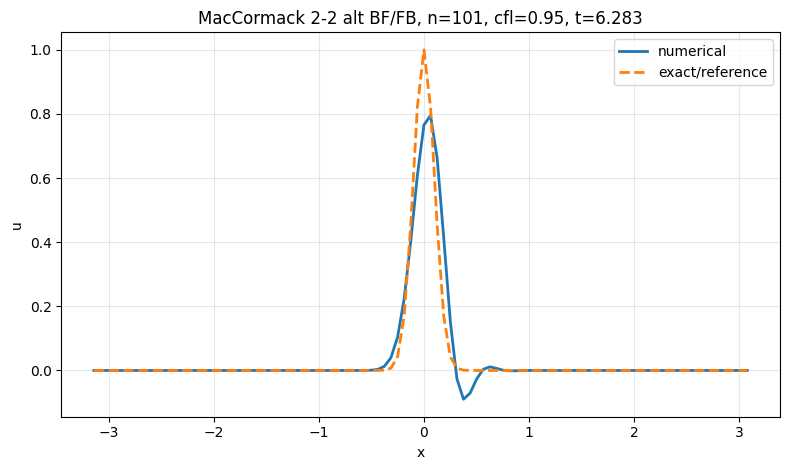

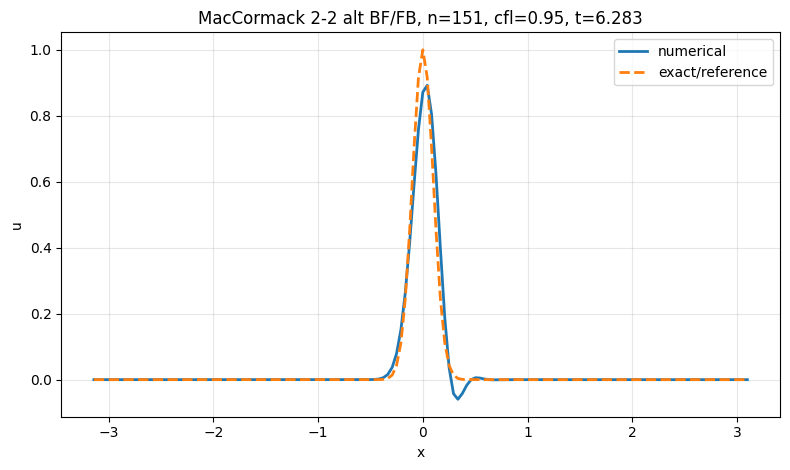

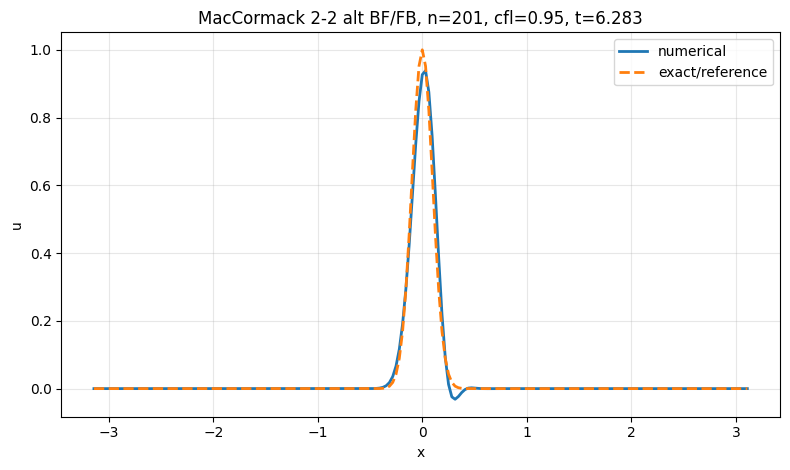

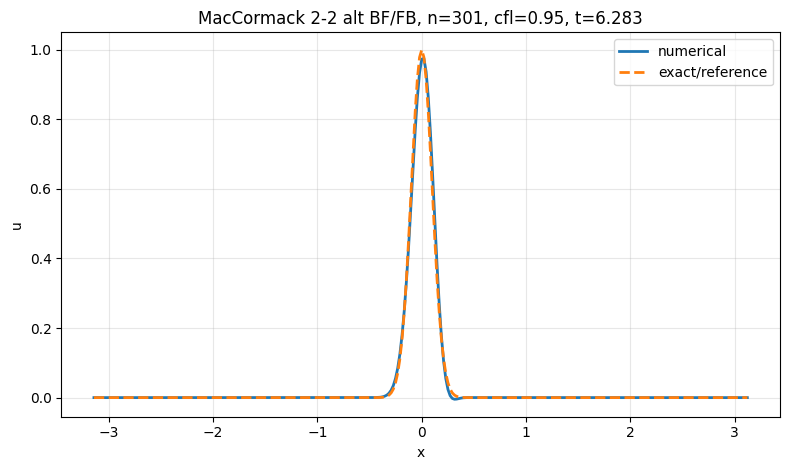

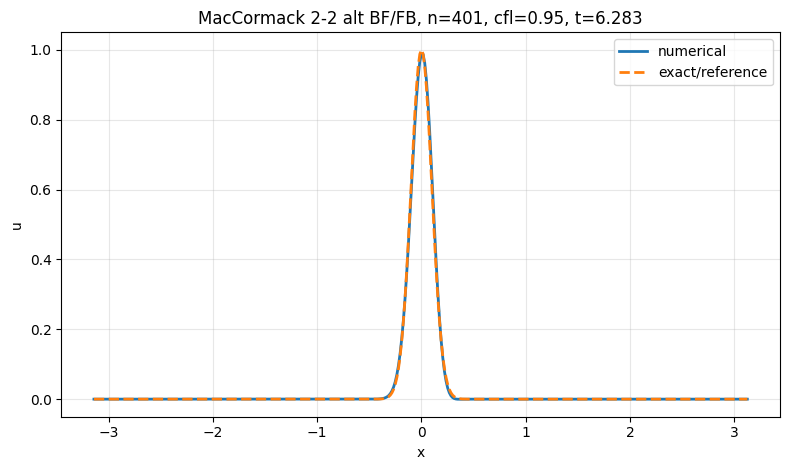

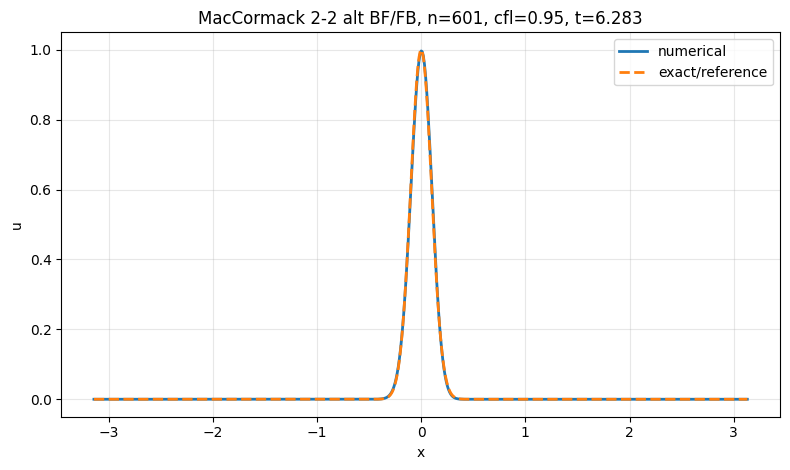

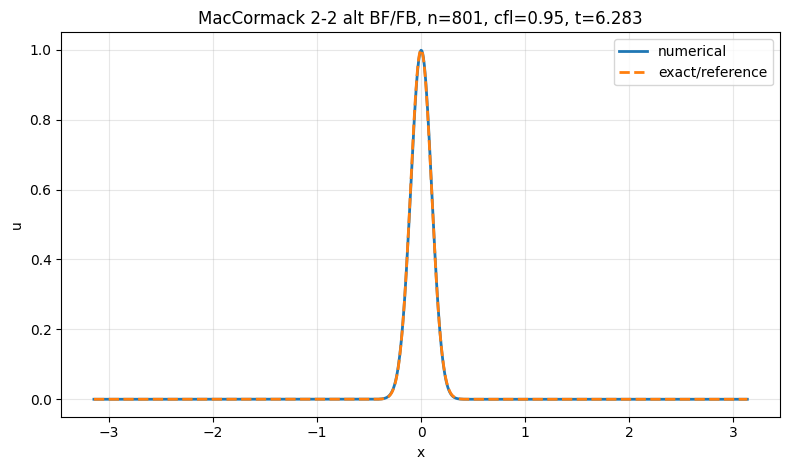

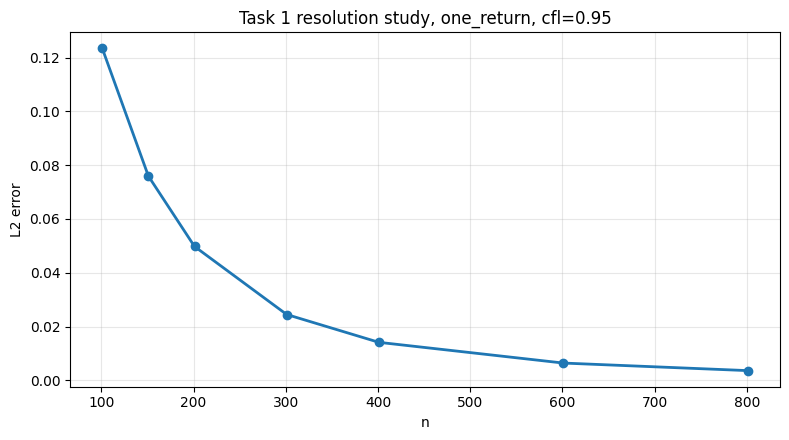

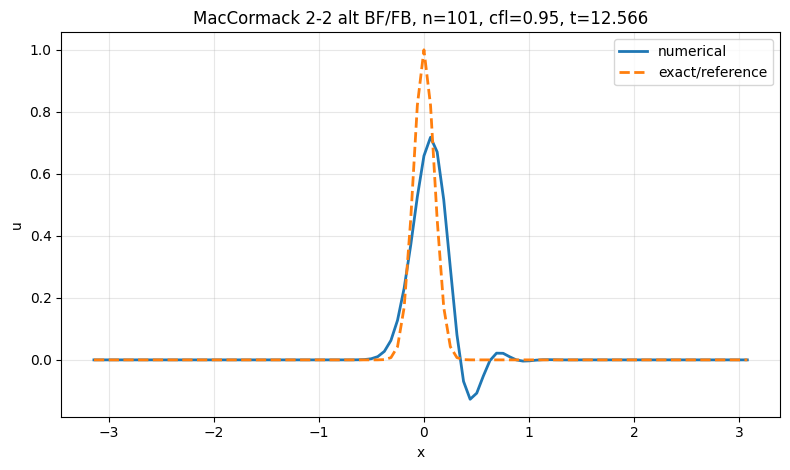

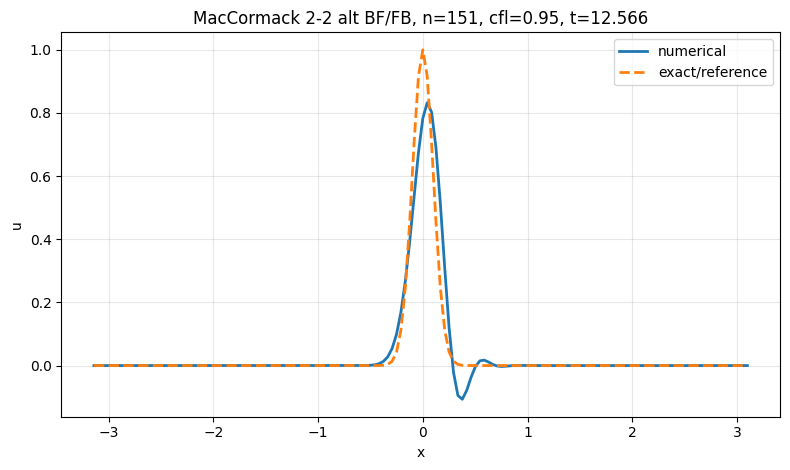

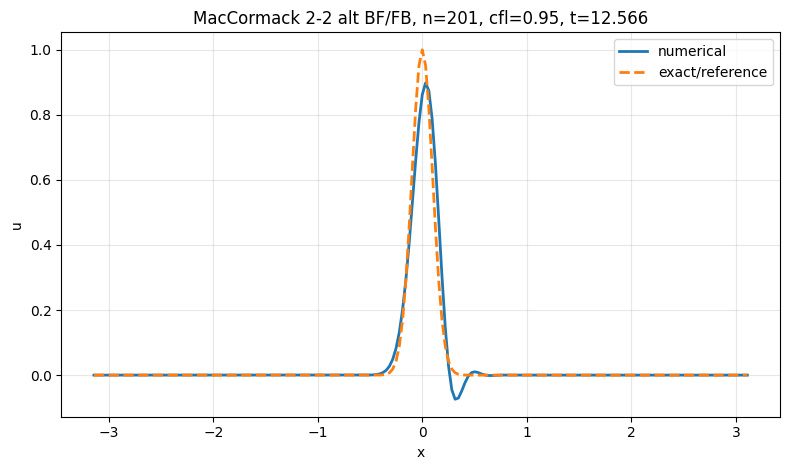

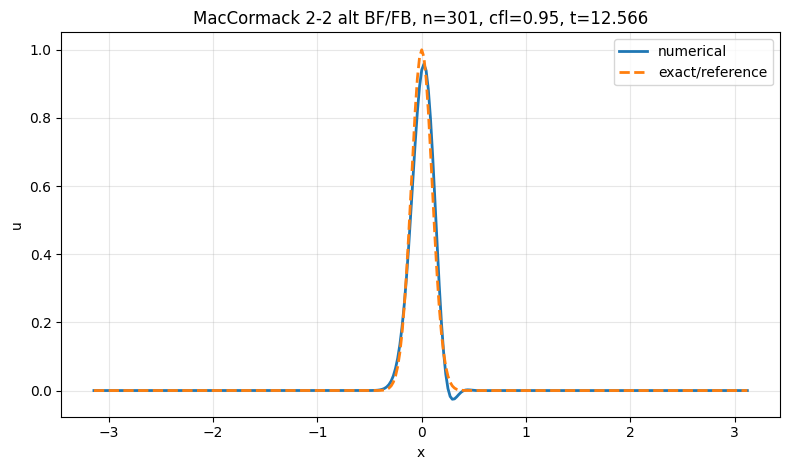

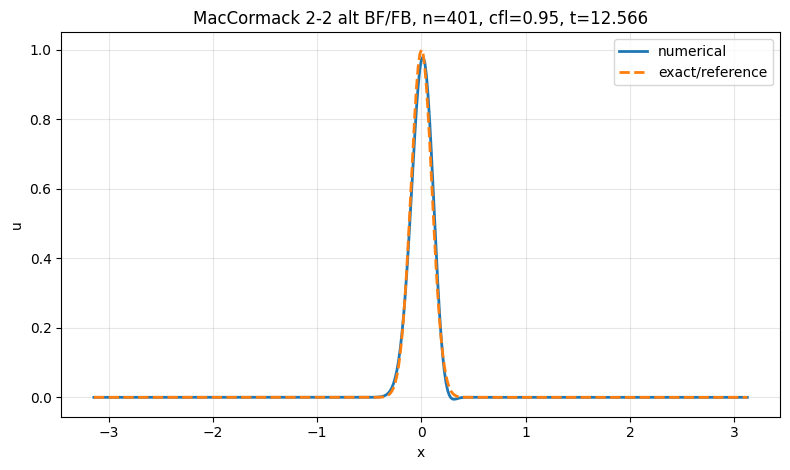

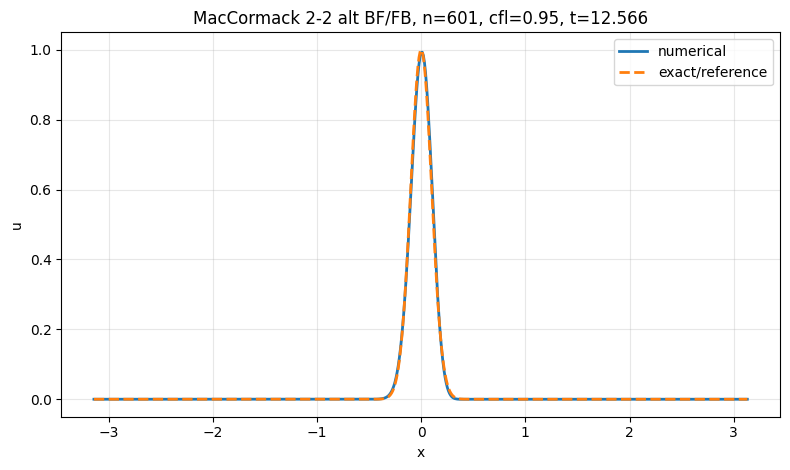

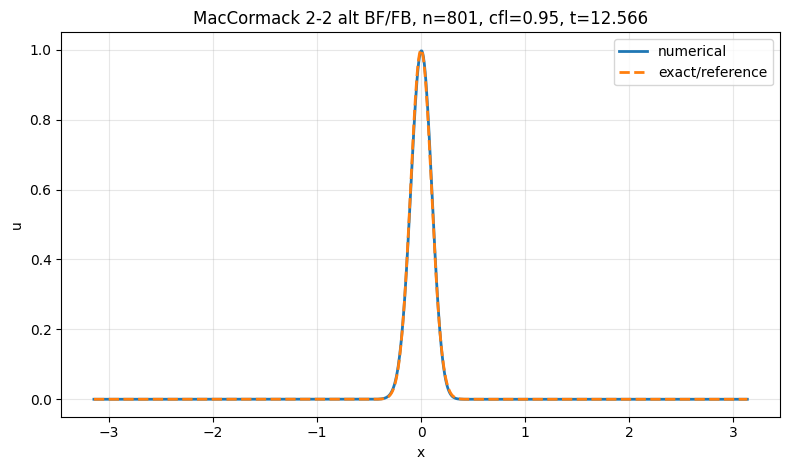

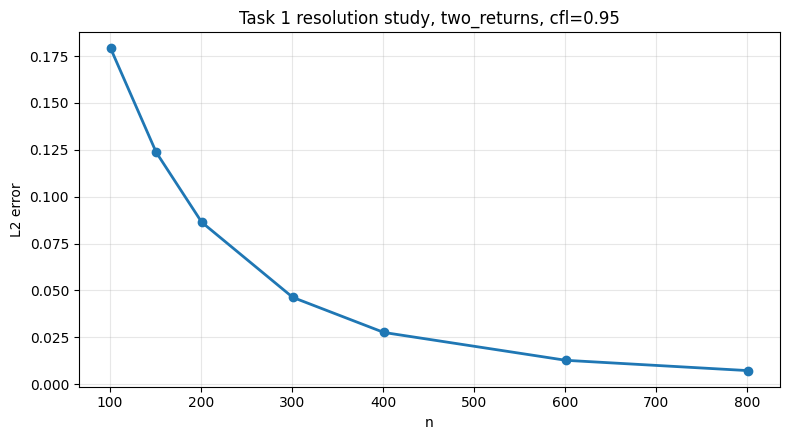

                     method    n         h        dt   cfl   t_final  \
0  MacCormack 2-2 alt BF/FB  101  0.062832  0.059690  0.95  6.283185   
1  MacCormack 2-2 alt BF/FB  151  0.041888  0.039794  0.95  6.283185   
2  MacCormack 2-2 alt BF/FB  201  0.031416  0.029845  0.95  6.283185   
3  MacCormack 2-2 alt BF/FB  301  0.020944  0.019897  0.95  6.283185   
4  MacCormack 2-2 alt BF/FB  401  0.015708  0.014923  0.95  6.283185   

   linf_error  l2_error  amplitude_num  amplitude_exact  amplitude_loss  \
0    0.244658  0.123386       0.795167              1.0        0.204833   
1    0.169536  0.075921       0.892274              1.0        0.107726   
2    0.117938  0.049780       0.938572              1.0        0.061428   
3    0.059511  0.024478       0.974921              1.0        0.025079   
4    0.034419  0.014131       0.988453              1.0        0.011547   

   peak_location_num  peak_location_exact  phase_shift  width_num  \
0       6.283185e-02         4.440892e-16     0

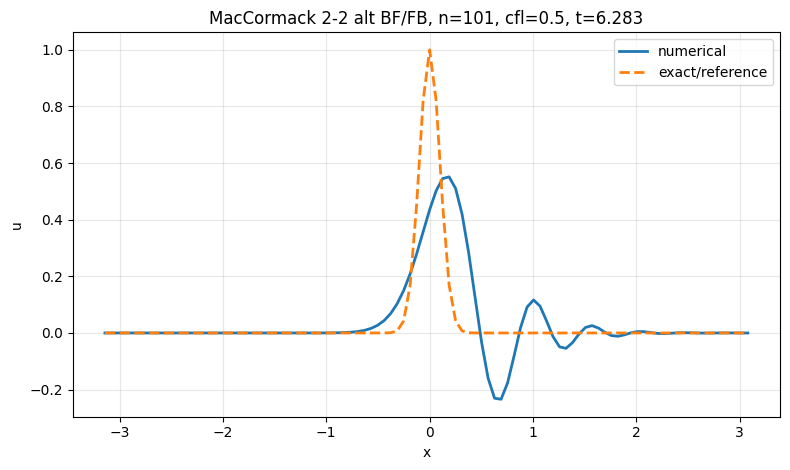

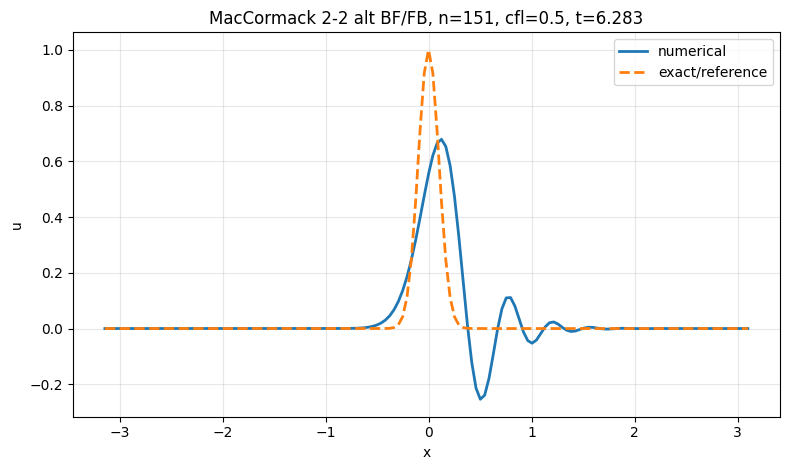

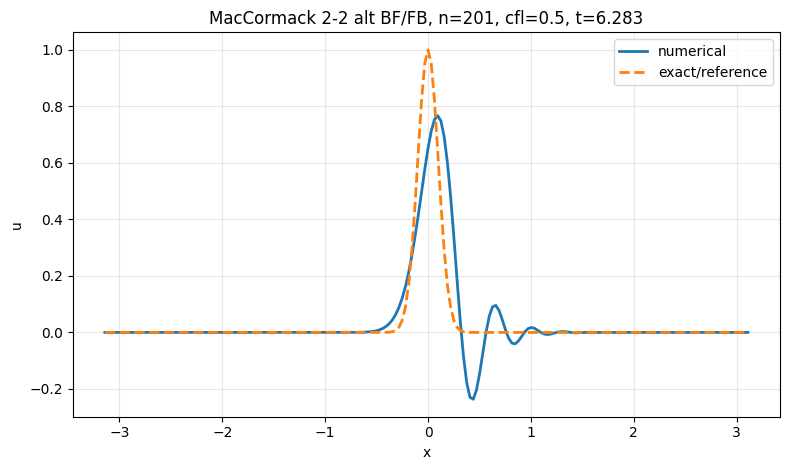

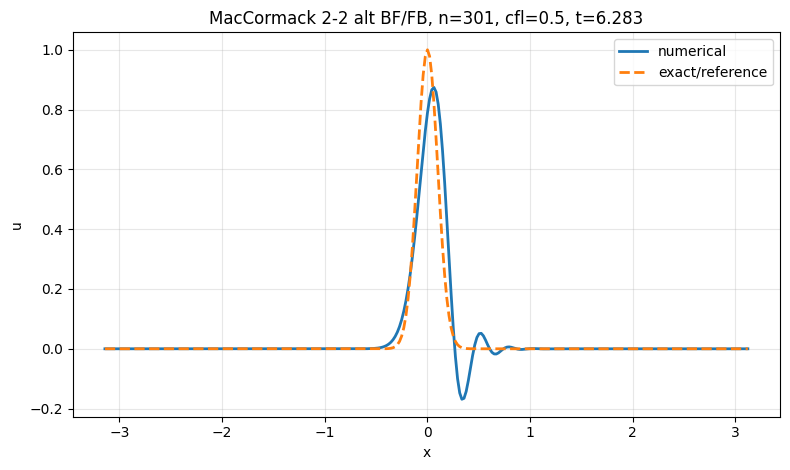

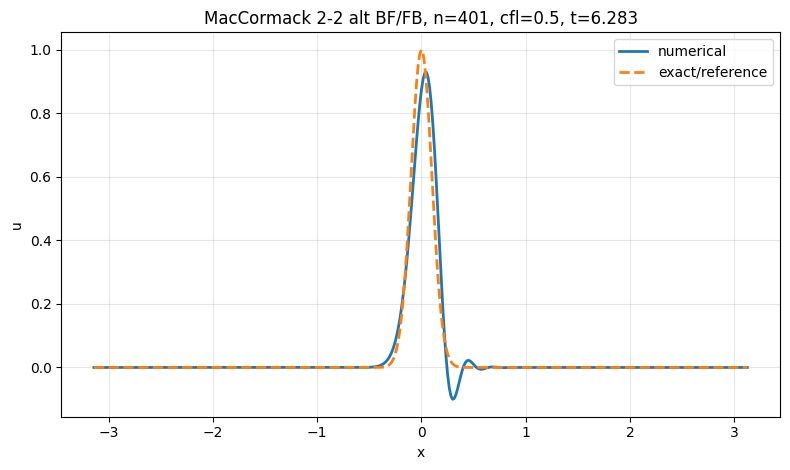

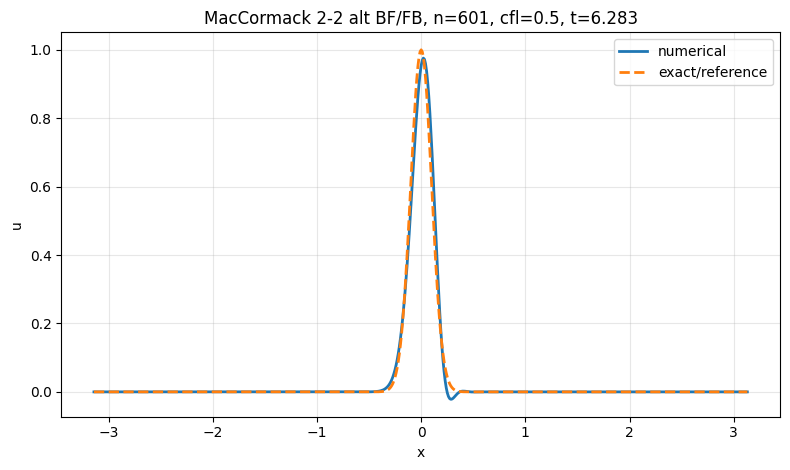

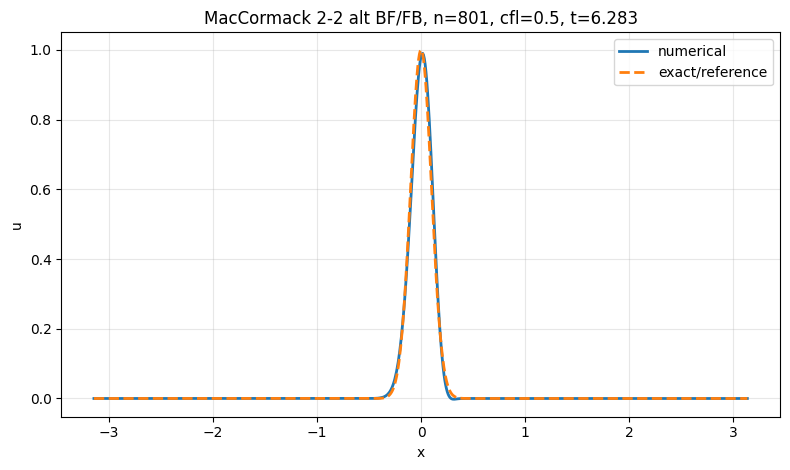

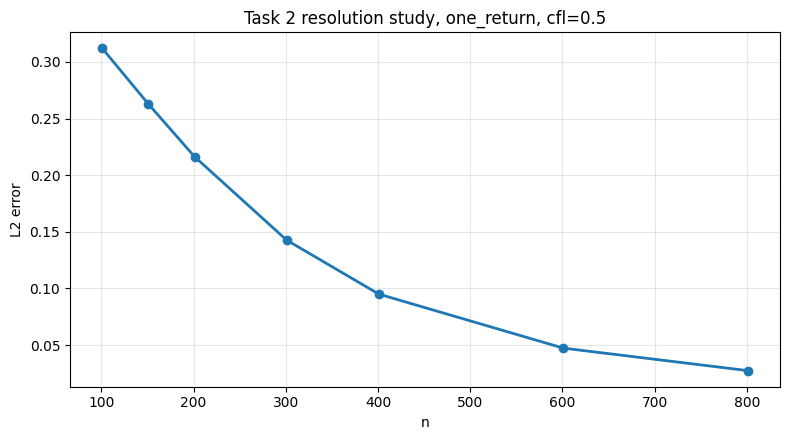

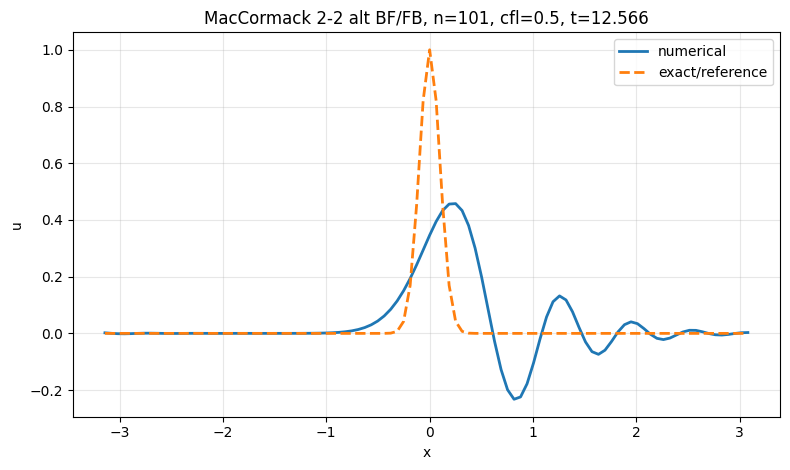

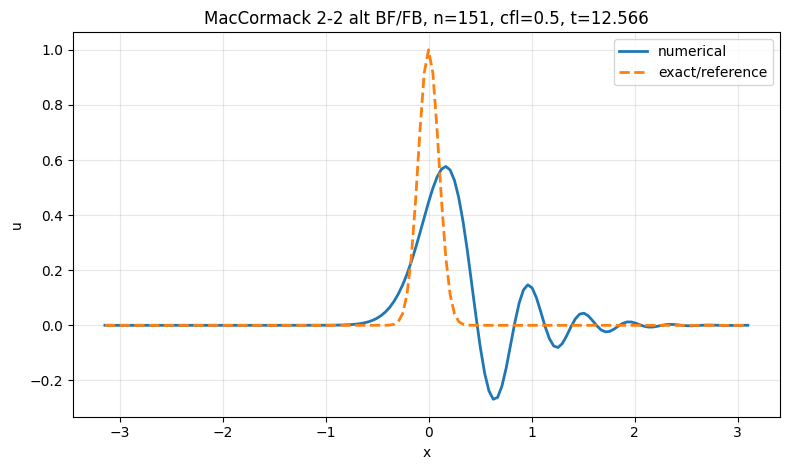

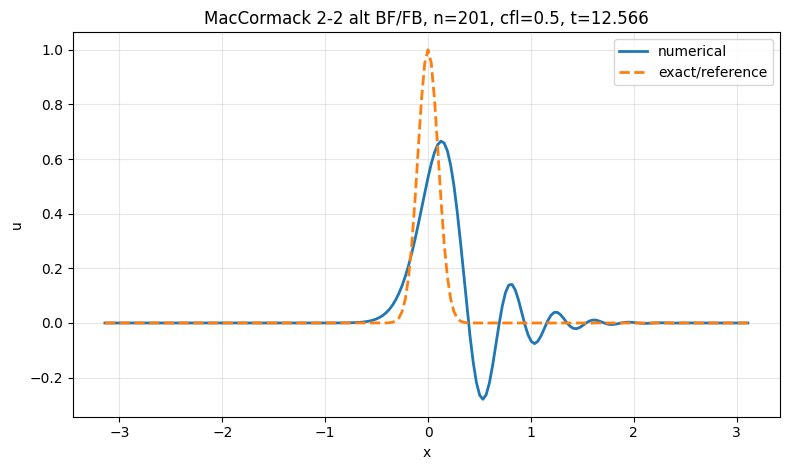

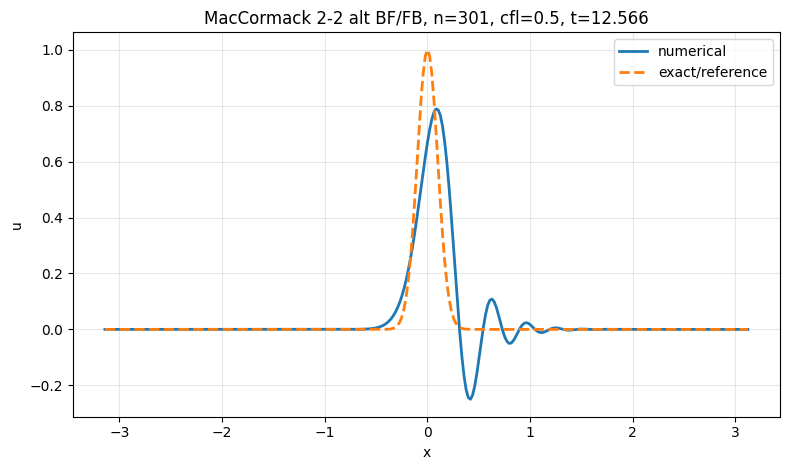

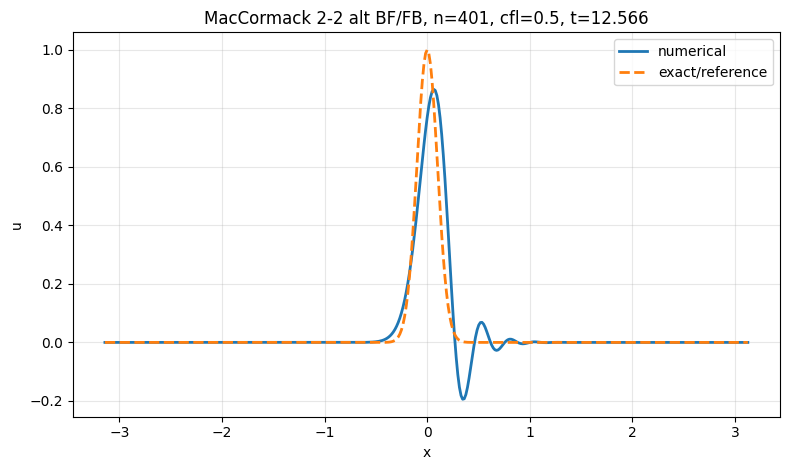

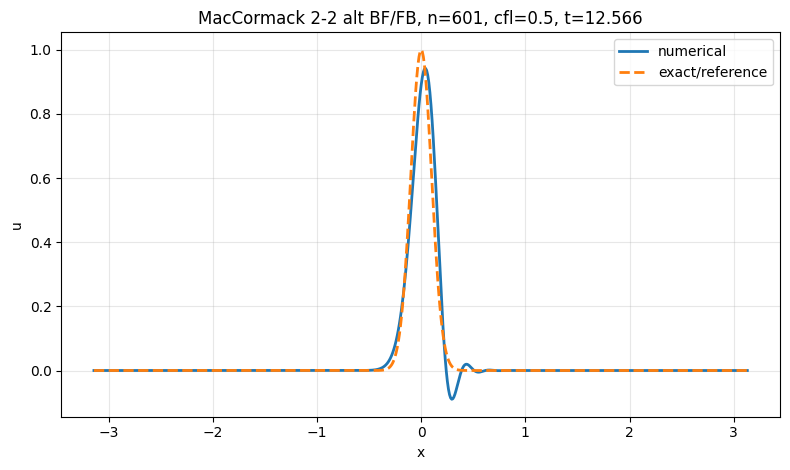

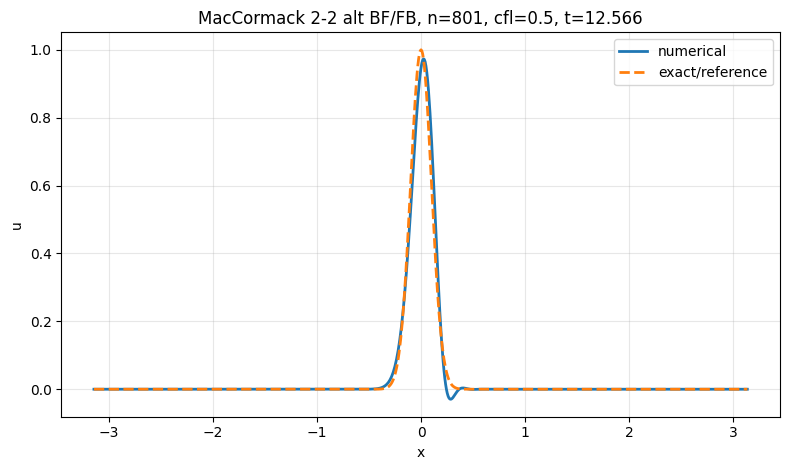

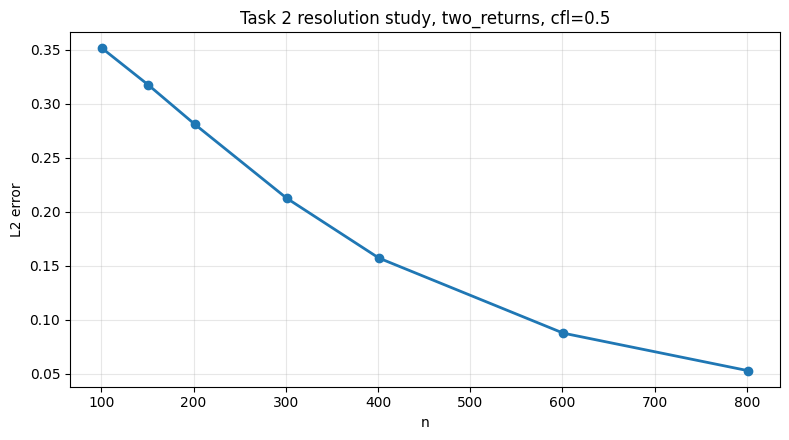

                     method    n         h        dt  cfl   t_final  \
0  MacCormack 2-2 alt BF/FB  101  0.062832  0.031416  0.5  6.283185   
1  MacCormack 2-2 alt BF/FB  151  0.041888  0.020944  0.5  6.283185   
2  MacCormack 2-2 alt BF/FB  201  0.031416  0.015708  0.5  6.283185   
3  MacCormack 2-2 alt BF/FB  301  0.020944  0.010472  0.5  6.283185   
4  MacCormack 2-2 alt BF/FB  401  0.015708  0.007854  0.5  6.283185   

   linf_error  l2_error  amplitude_num  amplitude_exact  amplitude_loss  \
0    0.564997  0.311956       0.551262              1.0        0.448738   
1    0.472931  0.262856       0.678855              1.0        0.321145   
2    0.433051  0.216387       0.767058              1.0        0.232942   
3    0.321805  0.142606       0.874348              1.0        0.125652   
4    0.228019  0.094932       0.929211              1.0        0.070789   

   peak_location_num  peak_location_exact  phase_shift  width_num  \
0           0.188496         4.440892e-16     0.18849

/content/mac24fb.py:7: RuntimeWarning: overflow encountered in multiply
  - 48.0 * np.roll(f, 1)
/content/mac24fb.py:6: RuntimeWarning: overflow encountered in subtract
  25.0 * f
/content/mac24fb.py:6: RuntimeWarning: overflow encountered in add
  25.0 * f
/content/mac24bf.py:11: RuntimeWarning: overflow encountered in multiply
  25.0 * f
/content/mac24bf.py:12: RuntimeWarning: overflow encountered in multiply
  - 48.0 * np.roll(f, 1)
/content/mac24bf.py:11: RuntimeWarning: overflow encountered in subtract
  25.0 * f
/content/mac24bf.py:13: RuntimeWarning: overflow encountered in multiply
  + 36.0 * np.roll(f, 2)
/content/mac24bf.py:11: RuntimeWarning: overflow encountered in add
  25.0 * f
/content/mac24bf.py:25: RuntimeWarning: overflow encountered in multiply
  -25.0 * f
/content/mac24bf.py:26: RuntimeWarning: overflow encountered in multiply
  + 48.0 * np.roll(f, -1)
/content/mac24bf.py:25: RuntimeWarning: overflow encountered in add
  -25.0 * f
/content/mac24bf.py:27: RuntimeWarn

                               method    n         h        dt   cfl  \
0  MacCormack 2-4 alt BF/FB, slow=0.5  101  0.062832  0.059690  0.95   
1  MacCormack 2-4 alt BF/FB, slow=0.5  151  0.041888  0.039794  0.95   
2  MacCormack 2-4 alt BF/FB, slow=0.5  201  0.031416  0.029845  0.95   
3  MacCormack 2-4 alt BF/FB, slow=0.5  301  0.020944  0.019897  0.95   
4  MacCormack 2-4 alt BF/FB, slow=0.5  401  0.015708  0.014923  0.95   

    t_final  linf_error  l2_error  amplitude_num  amplitude_exact  \
0  6.283185         NaN       NaN  1.711030e+171              NaN   
1  6.283185         NaN       NaN  1.397397e+260              NaN   
2  6.283185         NaN       NaN            NaN              NaN   
3  6.283185         NaN       NaN            NaN              NaN   
4  6.283185         NaN       NaN            NaN              NaN   

   amplitude_loss  peak_location_num  peak_location_exact  phase_shift  \
0             NaN          -0.188496                  NaN          NaN   
1   

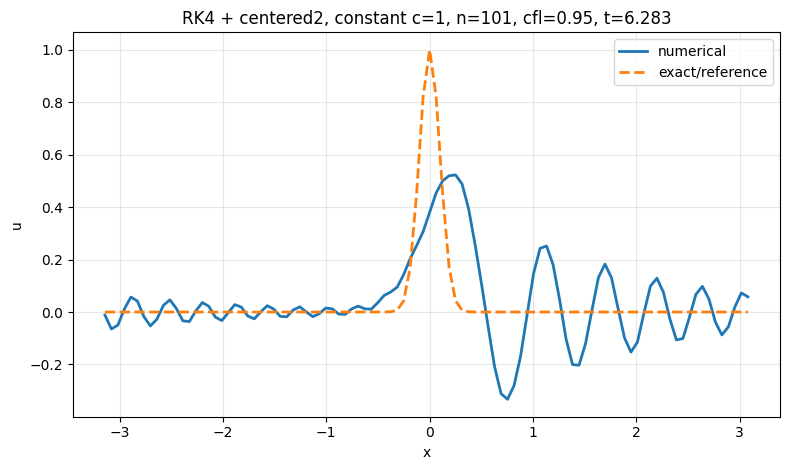

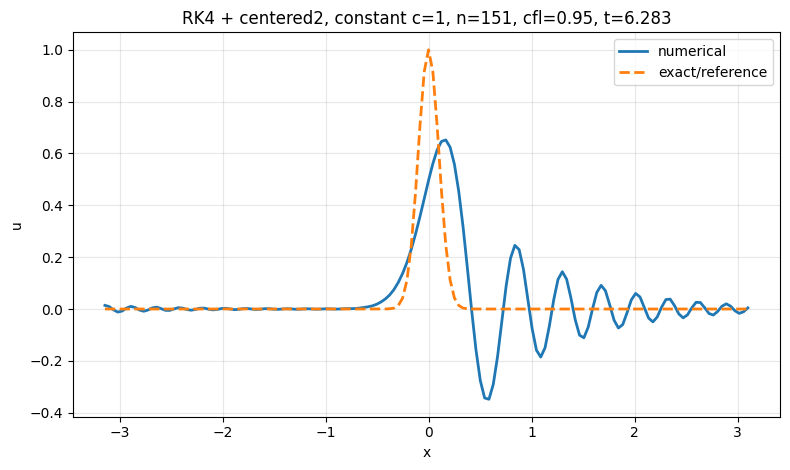

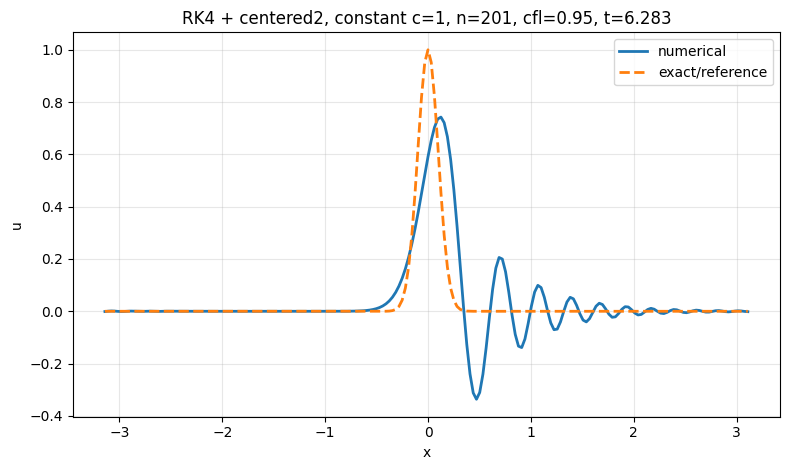

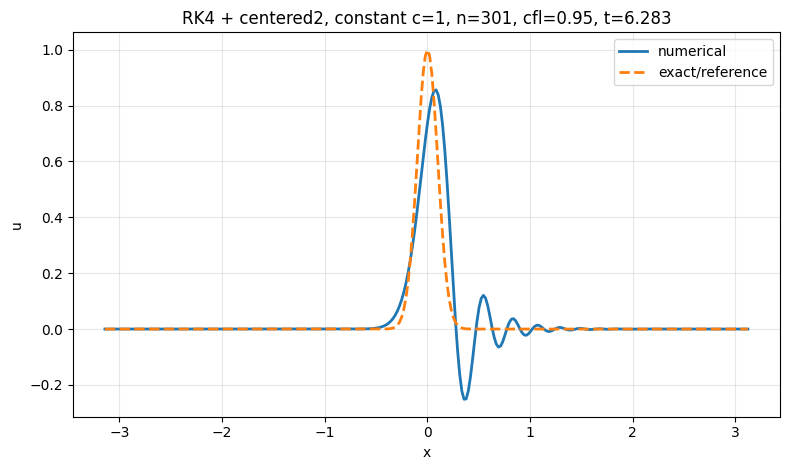

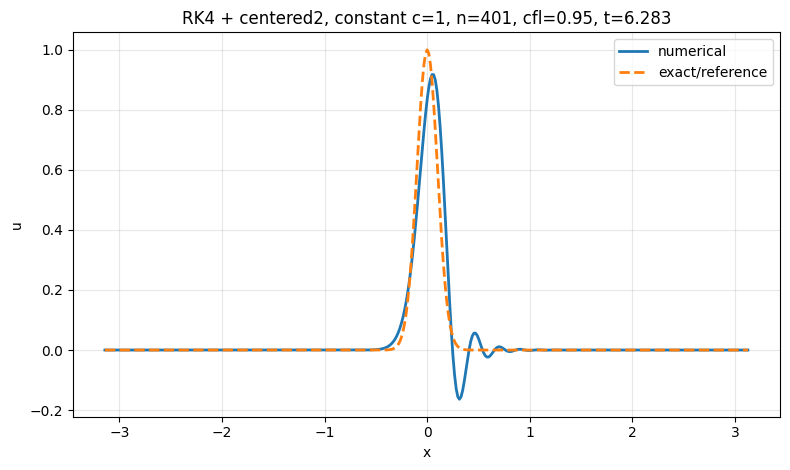

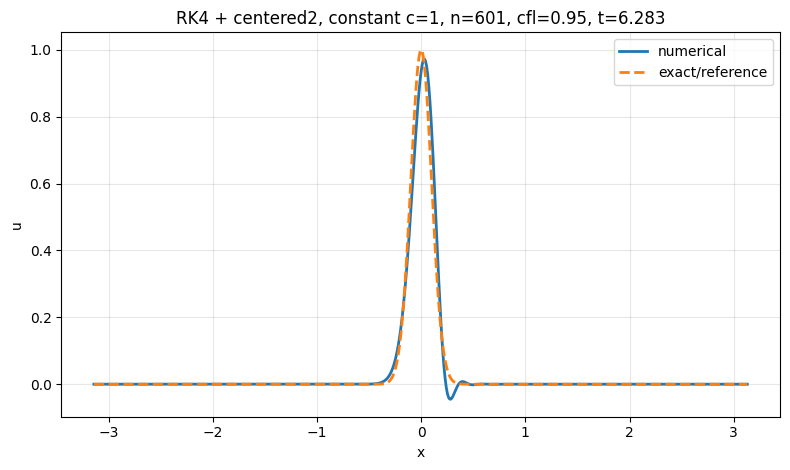

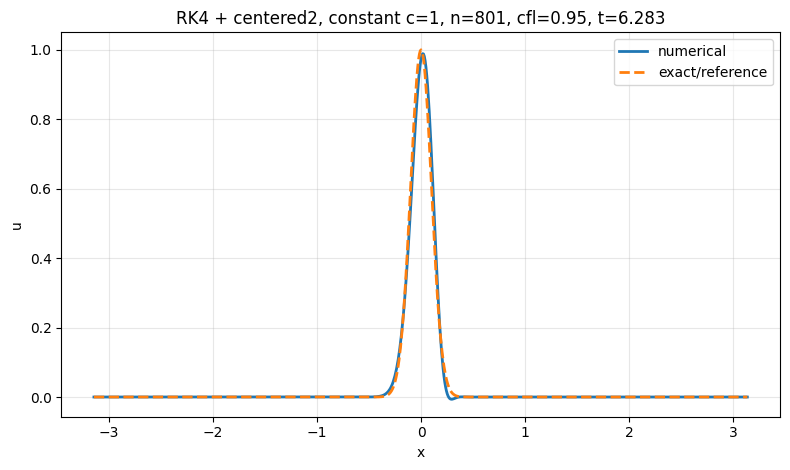

                          method    n         h        dt   cfl   t_final  \
0  RK4 + centered2, constant c=1  101  0.062832  0.059690  0.95  6.283185   
1  RK4 + centered2, constant c=1  151  0.041888  0.039794  0.95  6.283185   
2  RK4 + centered2, constant c=1  201  0.031416  0.029845  0.95  6.283185   
3  RK4 + centered2, constant c=1  301  0.020944  0.019897  0.95  6.283185   
4  RK4 + centered2, constant c=1  401  0.015708  0.014923  0.95  6.283185   

   linf_error  l2_error  amplitude_num  amplitude_exact  amplitude_loss  \
0    0.620174  0.400718       0.522695              1.0        0.477305   
1    0.515514  0.337729       0.652220              1.0        0.347780   
2    0.498449  0.279898       0.742707              1.0        0.257293   
3    0.400332  0.187949       0.856424              1.0        0.143576   
4    0.295904  0.126694       0.917616              1.0        0.082384   

   peak_location_num  peak_location_exact  phase_shift  width_num  \
0           0.251

In [32]:
import main_all
main_all.main()

# Periodic Pulse Propagation with MacCormack, 2–4 MacCormack, and Runge–Kutta Methods

## Project Overview

This project numerically investigates pulse propagation for the periodic partial differential equation

\[
u_t = (c(x)u)_x
\]

on the interval

\[
-\pi \le x \le \pi
\]

with Gaussian initial data

\[
u(0,x) = g(x) = e^{-\sigma x^2}, \qquad \sigma = 50.
\]

The main purpose of the project is to illustrate, through computation, several numerical concepts discussed in class:

- propagation of localized pulses on a periodic domain,
- dispersive error,
- dissipative error,
- behavior near and below the CFL stability limit,
- effects of variable wave speed,
- degradation of numerical solutions over long propagation distances,
- comparison of multiple time-stepping schemes.

The codebase is designed to run in **Python** and is fully compatible with **Google Colab**.

---

## Mathematical Background

We solve

\[
u_t = (c(x)u)_x.
\]

For the constant-speed case \(c(x)=1\), this reduces to

\[
u_t = u_x.
\]

With Gaussian initial data, the exact pulse travels to the left with speed \(c\). For constant \(c\), the exact solution is

\[
u(t,x) = g(x + ct).
\]

Because the computation is done on a finite interval with **periodic boundary conditions**, the solution is interpreted as a pulse traveling around a circle. For the time intervals considered in the project, the exact periodic reference is taken as

\[
u(t,x) = g(x+ct) + g(x+ct-2\pi) + g(x+ct-4\pi).
\]

These three image pulses are sufficient for one or two complete circuits of the computational domain.

---

## Physical and Numerical Interpretation

The initial Gaussian pulse is highly localized near \(x=0\). As time advances:

- the pulse propagates to the **left**,
- exits the interval at \(x=-\pi\),
- reappears at \(x=\pi\) because of periodicity,
- continues propagating around the domain,
- gradually accumulates **dissipative** and **dispersive** numerical errors.

### Dissipative error
Dissipation appears as:

- reduction in peak amplitude,
- flattening of the pulse,
- loss of sharpness.

### Dispersive error
Dispersion appears as:

- oscillations near the pulse,
- phase error in pulse location,
- widening or distortion of the pulse shape.

The project studies how these errors grow:

- after one return,
- after two returns,
- at different CFL numbers,
- in variable-speed media.

---

## Numerical Methods Implemented

### 1. Standard 2–2 MacCormack Scheme

The PDE is treated in conservative form:

\[
u_t = f_x, \qquad f = c(x)u.
\]

The numerical method does **not** hard-code the PDE directly into the update. Instead, it first builds a flux array \(f_j = c_j u_j\), then differences that flux.

Two variants are implemented:

- **Backward/Forward (BF)** MacCormack
- **Forward/Backward (FB)** MacCormack

These variants are alternated in time, which is standard good practice for MacCormack methods.

---

### 2. 2–4 MacCormack Scheme

A higher-order MacCormack method is also implemented:

- second-order in time,
- fourth-order in space through wider one-sided stencils.

Both variants are included:

- **2–4 BF**
- **2–4 FB**

These are also alternated during the run.

---

### 3. Runge–Kutta Method

To compare with MacCormack, the project also implements a Runge–Kutta solver.

In the provided codebase, this is:

- **RK4 in time**
- with a **second-order centered spatial derivative**

This gives an additional point of comparison for long-time pulse propagation and variable-speed problems.

---

## Periodic Grid Construction

The grid follows the assignment specification exactly.

If \(n\) denotes the natural point count on the full interval \([-\pi,\pi]\), then:

- the spacing is
  \[
  h = \frac{2\pi}{n-1},
  \]
- the stored grid has size \(n-1\),
- the point \(x=\pi\) is identified with \(x=-\pi\).

Thus, the actual computational grid is

\[
x_j = -\pi + jh, \qquad j=0,1,\dots,n-2.
\]

This is the natural periodic discretization required for the project.

---

## Speed Profiles Studied

### Constant speed
For Tasks 1 and 2:

\[
c(x)=1.
\]

### Piecewise constant speed
For Tasks 3 and 4:

\[
c(x)=
\begin{cases}
1, & |x| < 0.5,\\[4pt]
0.5, & |x| > 0.5.
\end{cases}
\]

### More extreme jump
For Task 5:

\[
c(x)=
\begin{cases}
1, & |x| < 0.5,\\[4pt]
0.3, & |x| > 0.5.
\end{cases}
\]

These discontinuous speed profiles create interfaces at \(x=\pm 0.5\), which make the solution more difficult to compute accurately.

---

## Assignment Tasks Covered

### Task 1
Solve the constant-speed problem with

- \(c(x)=1\),
- CFL near the stability limit, e.g. `cfl = 0.95`.

Study:

- pulse propagation,
- one return,
- two returns,
- dispersive error,
- dissipative error,
- grid resolution needed for a clean return.

---

### Task 2
Repeat Task 1 with

- `cfl = 0.5`.

This illustrates that running well below the stability limit can worsen performance for this problem.

---

### Task 3
Solve the variable-speed problem

\[
u_t = (c(x)u)_x
\]

with

\[
c(x)=1 \text{ for } |x|<0.5, \qquad c(x)=0.5 \text{ for } |x|>0.5.
\]

Study:

- pulse behavior at the interfaces,
- amplitude increase in the slow region,
- pulse narrowing,
- additional numerical degradation in the slow region.

---

### Task 4
Repeat Task 3 with the **2–4 MacCormack** scheme and compare with the standard 2–2 MacCormack scheme.

---

### Task 5
Repeat the variable-speed experiment with a stronger jump:

\[
c=0.3
\]

in the slow region. This makes the pulse even narrower and more difficult to resolve.

---

### Task 6
Implement and test **Runge–Kutta** methods on the same class of problems.

---

### Task 7
Produce a brief report summarizing:

- dissipative effects,
- dispersive effects,
- effect of longer propagation time,
- effect of lower CFL number,
- effect of slow/fast speed regions,
- code structure.

---

## Repository Structure

A typical modular structure for this project is:

```text
periodic_pulse_project/
│
├── config.py
├── grid.py
├── initial_data.py
├── speed_profiles.py
├── exact_solutions.py
├── boundary.py
├── flux.py
├── macbf.py
├── macfb.py
├── mac24bf.py
├── mac24fb.py
├── rk_schemes.py
├── time_integrators.py
├── diagnostics.py
├── plotting.py
├── experiments.py
├── report_tables.py
├── tests_basic.py
├── main_task1.py
├── main_task2.py
├── main_task3.py
├── main_task4.py
├── main_task5.py
├── main_task6.py
├── main_all.py
└── README.md